## 代谢组/脂质组表型整理

这一步把原始表型文件整理成一个干净、适合下游分析的表。

主要处理内容：

1. 读取原始代谢组/脂质组结果表  
2. 清洗 `sample` 列，统一样本名格式  
   - 例如 `CIMA_H019` -> `CIMA19`
   - `CIMA_H015\t` -> `CIMA15`
   - `CIMA_451` -> `CIMA451`
3. 其余列尽量转成数值型
4. 输出整理后的主表
5. 额外输出一个 sample 映射表，便于人工核对


In [1]:
from pathlib import Path
import re
import pandas as pd

# ===== 路径设置（相对项目根目录）=====
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    PROJECT_ROOT = PROJECT_ROOT.parent

if PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    raise RuntimeError("未找到项目根目录 CIMA_multiomics_regulation，请在项目目录内运行该脚本。")

INPUT_FILE = PROJECT_ROOT / "data/raw/CIMA/Metabolites_and_Lipids/CIMA_Sample_Plasma_Metabolites_and_Lipids_Results.csv"
OUTPUT_DIR = PROJECT_ROOT / "data/processed/CIMA/phenotype"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "CIMA_metabolites_lipids_clean.tsv"
SAMPLE_MAP_FILE = OUTPUT_DIR / "CIMA_metabolites_lipids_sample_map.tsv"

print(f"INPUT_FILE = {INPUT_FILE}")
print(f"exists = {INPUT_FILE.exists()}")

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"找不到输入文件: {INPUT_FILE}")


# ===== 读取原始表 =====
df = pd.read_csv(INPUT_FILE)
print("原始表 shape:", df.shape)
print("前5列:", df.columns[:5].tolist())

if "sample" not in df.columns:
    raise ValueError("输入表中没有找到 'sample' 列，请先检查原始文件列名。")


# ===== sample 清洗函数 =====
def clean_sample_id(x):
    """
    统一样本名格式：
    - 去掉首尾空格、制表符
    - CIMA_H019 -> CIMA19
    - CIMA_H015\t -> CIMA15
    - CIMA_451 -> CIMA451
    - 尽量保留 CIMA + 数字 的格式
    """
    if pd.isna(x):
        return pd.NA

    s = str(x).strip()
    s = s.replace("\t", "").replace(" ", "")
    s = s.upper()

    m = re.match(r"^CIMA(?:[_-]?H|[_-])?0*([0-9]+)$", s)
    if m:
        return f"CIMA{int(m.group(1))}"

    m2 = re.search(r"CIMA.*?([0-9]+)$", s)
    if m2:
        return f"CIMA{int(m2.group(1))}"

    return s


# ===== 清洗 sample =====
sample_map = df[["sample"]].copy()
sample_map["sample_raw"] = sample_map["sample"]
sample_map["sample_clean"] = sample_map["sample_raw"].map(clean_sample_id)

df["sample"] = df["sample"].map(clean_sample_id)

other_cols = [c for c in df.columns if c != "sample"]
df = df[["sample"] + other_cols]


# ===== 数值列转 numeric =====
for col in df.columns:
    if col == "sample":
        continue
    df[col] = pd.to_numeric(df[col], errors="coerce")


# ===== 基本检查 =====
print("\n清洗后 shape:", df.shape)
print("sample 示例:")
print(df["sample"].head().tolist())

print("\n缺失 sample 数量:", df["sample"].isna().sum())
print("sample 去重后数量:", df["sample"].nunique(dropna=True))
print("是否有重复 sample:", df["sample"].duplicated().any())

dup_df = df[df["sample"].duplicated(keep=False)].sort_values("sample")
if len(dup_df) > 0:
    print("\n重复 sample 示例:")
    print(dup_df[["sample"]].head(20))


# ===== sample 映射表整理 =====
sample_map = sample_map.rename(columns={"sample": "sample_original"})
sample_map = sample_map[["sample_raw", "sample_clean"]].drop_duplicates()

print("\nsample 映射表示例:")
print(sample_map.head(10))


# ===== 保存结果 =====
df.to_csv(OUTPUT_FILE, sep="\t", index=False)
sample_map.to_csv(SAMPLE_MAP_FILE, sep="\t", index=False)

print("\n已保存：")
print(OUTPUT_FILE)
print(SAMPLE_MAP_FILE)


INPUT_FILE = /data/work/CIMA_multiomics_regulation/data/raw/CIMA/Metabolites_and_Lipids/CIMA_Sample_Plasma_Metabolites_and_Lipids_Results.csv
exists = True
原始表 shape: (390, 1550)
前5列: ['sample', 'O-Phosphoryl-ethanolamine', 'Acesulfame', 'Acetic acid', 'Propanoic acid']

清洗后 shape: (390, 1550)
sample 示例:
['CIMA15', 'CIMA16', 'CIMA17', 'CIMA18', 'CIMA19']

缺失 sample 数量: 0
sample 去重后数量: 390
是否有重复 sample: False

sample 映射表示例:
  sample_raw sample_clean
0  CIMA_H015       CIMA15
1  CIMA_H016       CIMA16
2  CIMA_H017       CIMA17
3  CIMA_H018       CIMA18
4  CIMA_H019       CIMA19
5  CIMA_H020       CIMA20
6  CIMA_H021       CIMA21
7  CIMA_H022       CIMA22
8  CIMA_H023       CIMA23
9  CIMA_H024       CIMA24

已保存：
/data/work/CIMA_multiomics_regulation/data/processed/CIMA/phenotype/CIMA_metabolites_lipids_clean.tsv
/data/work/CIMA_multiomics_regulation/data/processed/CIMA/phenotype/CIMA_metabolites_lipids_sample_map.tsv


: 

## 整理成 plink2 可直接使用的 phenotype 文件

这一步把原始代谢组/脂质组表型表整理成 plink2 可直接读取的格式。

目标输出格式：

- 前两列固定为 `FID` 和 `IID`
- 两列都使用 `BGE_ID`
- 后面每一列都是一个表型
- 未匹配到 `BGE_ID` 的样本直接去掉
- 输出为 `tsv`

这样生成的文件可以直接用于 plink2 的 `--pheno`。

In [3]:
from pathlib import Path
import re
import pandas as pd

# ===== 路径设置（相对项目根目录）=====
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    PROJECT_ROOT = PROJECT_ROOT.parent

if PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    raise RuntimeError("未找到项目根目录 CIMA_multiomics_regulation，请在项目目录内运行该脚本。")

INPUT_FILE = PROJECT_ROOT / "data/raw/CIMA/Metabolites_and_Lipids/CIMA_Sample_Plasma_Metabolites_and_Lipids_Results.csv"
META_FILE = PROJECT_ROOT / "data/processed/CIMA/meta_inventory/basic_id_sex_age.csv"

OUTPUT_DIR = PROJECT_ROOT / "data/processed/CIMA/phenotype"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "CIMA_metabolites_lipids_pheno_plink.tsv"
SAMPLE_MAP_FILE = OUTPUT_DIR / "CIMA_metabolites_lipids_sample_map.tsv"
UNMATCHED_FILE = OUTPUT_DIR / "CIMA_metabolites_lipids_unmatched_samples.tsv"

print(f"INPUT_FILE = {INPUT_FILE}")
print(f"META_FILE  = {META_FILE}")
print(f"INPUT exists = {INPUT_FILE.exists()}")
print(f"META  exists = {META_FILE.exists()}")

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"找不到输入文件: {INPUT_FILE}")
if not META_FILE.exists():
    raise FileNotFoundError(f"找不到 meta 文件: {META_FILE}")


# ===== 读取数据 =====
df = pd.read_csv(INPUT_FILE)
meta = pd.read_csv(META_FILE)

print("\n原始表 shape:", df.shape)
print("meta 表 shape:", meta.shape)

if "sample" not in df.columns:
    raise ValueError("输入表中没有找到 'sample' 列。")

required_meta_cols = ["BGE_ID", "CIMA_ID"]
missing_meta_cols = [c for c in required_meta_cols if c not in meta.columns]
if missing_meta_cols:
    raise ValueError(f"meta 表缺少必要列: {missing_meta_cols}")


# ===== sample 清洗函数 =====
def clean_sample_id(x):
    if pd.isna(x):
        return pd.NA

    s = str(x).strip()
    s = s.replace("\t", "").replace(" ", "")
    s = s.upper()

    m = re.match(r"^CIMA(?:[_-]?H|[_-])?0*([0-9]+)$", s)
    if m:
        return f"CIMA{int(m.group(1))}"

    m2 = re.search(r"CIMA.*?([0-9]+)$", s)
    if m2:
        return f"CIMA{int(m2.group(1))}"

    return s


# ===== 清洗 sample =====
df["sample_raw"] = df["sample"]
df["sample_clean"] = df["sample_raw"].map(clean_sample_id)

meta = meta.copy()
meta["CIMA_ID"] = meta["CIMA_ID"].astype(str).str.strip().str.upper()
meta["BGE_ID"] = meta["BGE_ID"].astype(str).str.strip()


# ===== sample 对照表 =====
sample_map = (
    df[["sample_raw", "sample_clean"]]
    .drop_duplicates()
    .merge(
        meta[["BGE_ID", "CIMA_ID"]],
        left_on="sample_clean",
        right_on="CIMA_ID",
        how="left"
    )
    [["sample_raw", "sample_clean", "BGE_ID", "CIMA_ID"]]
    .drop_duplicates()
)

print("\nsample 对照表示例:")
print(sample_map.head(10))


# ===== 合并 BGE_ID 回主表 =====
df = df.merge(
    meta[["BGE_ID", "CIMA_ID"]],
    left_on="sample_clean",
    right_on="CIMA_ID",
    how="left"
)

# ===== 未匹配样本 =====
unmatched = (
    df.loc[df["BGE_ID"].isna(), ["sample_raw", "sample_clean"]]
    .drop_duplicates()
    .copy()
)

# 只保留匹配成功样本
df = df[df["BGE_ID"].notna()].copy()

# ===== 删除不再需要的列 =====
drop_cols = [c for c in ["sample", "sample_raw", "sample_clean", "CIMA_ID"] if c in df.columns]
df = df.drop(columns=drop_cols)

# ===== 改成 plink2 需要的 FID / IID =====
df = df.rename(columns={"BGE_ID": "IID"})
df.insert(0, "FID", df["IID"])

# 关键：强制把 IID 放到第 2 列
other_cols = [c for c in df.columns if c not in ["FID", "IID"]]
df = df[["FID", "IID"] + other_cols]

# ===== 其余列转数值 =====
for col in df.columns:
    if col in {"FID", "IID"}:
        continue
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 去掉重复 IID =====
dup_iid = df["IID"].duplicated(keep=False)
if dup_iid.any():
    print("\n发现重复 IID，示例：")
    print(df.loc[dup_iid, ["FID", "IID"]].head(20))
    df = df.drop_duplicates(subset=["IID"], keep="first").copy()
    print(f"已按 IID 去重，当前样本数: {df.shape[0]}")

# ===== 删除全 NA 表型列 =====
pheno_cols = [c for c in df.columns if c not in {"FID", "IID"}]
all_na_cols = [c for c in pheno_cols if df[c].isna().all()]
if all_na_cols:
    print(f"\n删除全 NA 表型列数: {len(all_na_cols)}")
    print("示例列:", all_na_cols[:10])
    df = df.drop(columns=all_na_cols)

# ===== 再检查一次 =====
pheno_cols = [c for c in df.columns if c not in {"FID", "IID"}]

print("\n整理后主表 shape:", df.shape)
print("前10列:", df.columns[:10].tolist())
print("FID 是否缺失:", df["FID"].isna().sum())
print("IID 是否缺失:", df["IID"].isna().sum())
print("IID 是否重复:", df["IID"].duplicated().any())
print("表型列数:", len(pheno_cols))

print("\n匹配统计:")
print(f"sample 去重后总数: {len(sample_map)}")
print(f"成功匹配 BGE_ID:   {sample_map['BGE_ID'].notna().sum()}")
print(f"未匹配样本数:      {sample_map['BGE_ID'].isna().sum()}")

if len(unmatched) > 0:
    print("\n未匹配样本示例:")
    print(unmatched.head(20))

# ===== 保存 =====
df.to_csv(OUTPUT_FILE, sep="\t", index=False)
sample_map.to_csv(SAMPLE_MAP_FILE, sep="\t", index=False)
unmatched.to_csv(UNMATCHED_FILE, sep="\t", index=False)

print("\n已保存：")
print(OUTPUT_FILE)
print(SAMPLE_MAP_FILE)
print(UNMATCHED_FILE)

print("\n输出文件前5行预览:")
print(df.head())

INPUT_FILE = /data/work/CIMA_multiomics_regulation/data/raw/CIMA/Metabolites_and_Lipids/CIMA_Sample_Plasma_Metabolites_and_Lipids_Results.csv
META_FILE  = /data/work/CIMA_multiomics_regulation/data/processed/CIMA/meta_inventory/basic_id_sex_age.csv
INPUT exists = True
META  exists = True

原始表 shape: (390, 1550)
meta 表 shape: (467, 4)

sample 对照表示例:
  sample_raw sample_clean          BGE_ID CIMA_ID
0  CIMA_H015       CIMA15  E-B21433880158  CIMA15
1  CIMA_H016       CIMA16  E-B21454468614  CIMA16
2  CIMA_H017       CIMA17  E-B21481266996  CIMA17
3  CIMA_H018       CIMA18  E-B21519886974  CIMA18
4  CIMA_H019       CIMA19  E-B21540551243  CIMA19
5  CIMA_H020       CIMA20  E-B21546282403  CIMA20
6  CIMA_H021       CIMA21  E-B21559280278  CIMA21
7  CIMA_H022       CIMA22  E-B21576997531  CIMA22
8  CIMA_H023       CIMA23  E-B21588672872  CIMA23
9  CIMA_H024       CIMA24  E-B21622568877  CIMA24

整理后主表 shape: (390, 1551)
前10列: ['FID', 'IID', 'O-Phosphoryl-ethanolamine', 'Acesulfame', 'Acetic a

In [4]:
# ===== 查看表型缺失情况 =====
import pandas as pd

PHENO_FILE = OUTPUT_DIR / "CIMA_metabolites_lipids_pheno_plink.tsv"

pheno = pd.read_csv(PHENO_FILE, sep="\t")
print("pheno shape:", pheno.shape)

# 只看表型列，不看 FID / IID
pheno_cols = [c for c in pheno.columns if c not in ["FID", "IID"]]

missing_summary = pd.DataFrame({
    "phenotype": pheno_cols,
    "n_missing": [pheno[c].isna().sum() for c in pheno_cols],
    "missing_rate": [pheno[c].isna().mean() for c in pheno_cols],
    "n_non_missing": [pheno[c].notna().sum() for c in pheno_cols],
})

missing_summary = missing_summary.sort_values(
    ["missing_rate", "n_missing", "phenotype"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n缺失情况前10个表型：")
print(missing_summary.head(10))

print("\n缺失率分布：")
print(missing_summary["missing_rate"].describe())

print("\n缺失率 > 0.2 的表型数:", (missing_summary["missing_rate"] > 0.2).sum())
print("缺失率 > 0.5 的表型数:", (missing_summary["missing_rate"] > 0.5).sum())
print("全缺失表型数:", (missing_summary["missing_rate"] == 1).sum())

MISSING_SUMMARY_FILE = OUTPUT_DIR / "CIMA_metabolites_lipids_missing_summary.tsv"
missing_summary.to_csv(MISSING_SUMMARY_FILE, sep="\t", index=False)

print("\n已保存：")
print(MISSING_SUMMARY_FILE)

pheno shape: (390, 1551)

缺失情况前10个表型：
      phenotype  n_missing  missing_rate  n_non_missing
0  PG 18:3-22:3        376      0.964103             14
1  PS 20:0-20:0        374      0.958974             16
2  PG 18:4-20:0        370      0.948718             20
3  PG 18:4-20:1        369      0.946154             21
4  PS 20:4-20:4        369      0.946154             21
5  PG 16:1-20:2        366      0.938462             24
6  PE 18:0-20:0        364      0.933333             26
7  PS 20:3-20:4        364      0.933333             26
8  PG 16:1-20:1        356      0.912821             34
9  PG 16:1-20:0        353      0.905128             37

缺失率分布：
count    1549.000000
mean        0.236376
std         0.280656
min         0.000000
25%         0.000000
50%         0.046154
75%         0.535897
max         0.964103
Name: missing_rate, dtype: float64

缺失率 > 0.2 的表型数: 665
缺失率 > 0.5 的表型数: 413
全缺失表型数: 0

已保存：
/data/work/CIMA_multiomics_regulation/data/processed/CIMA/phenotype/CIMA_metab

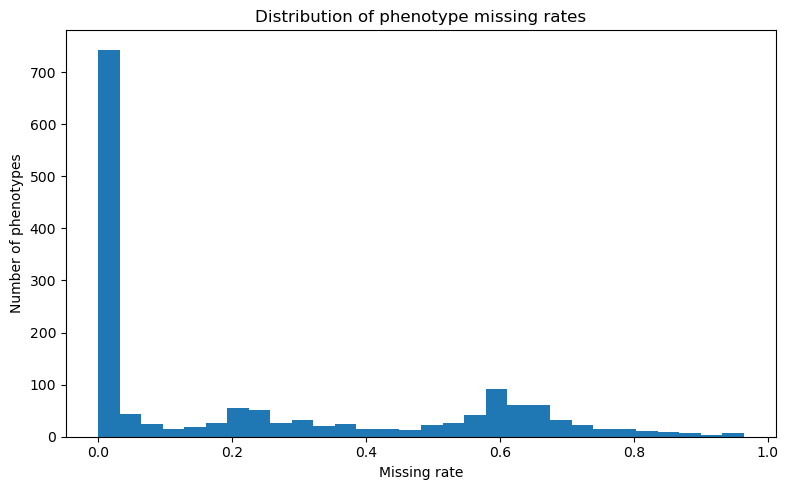

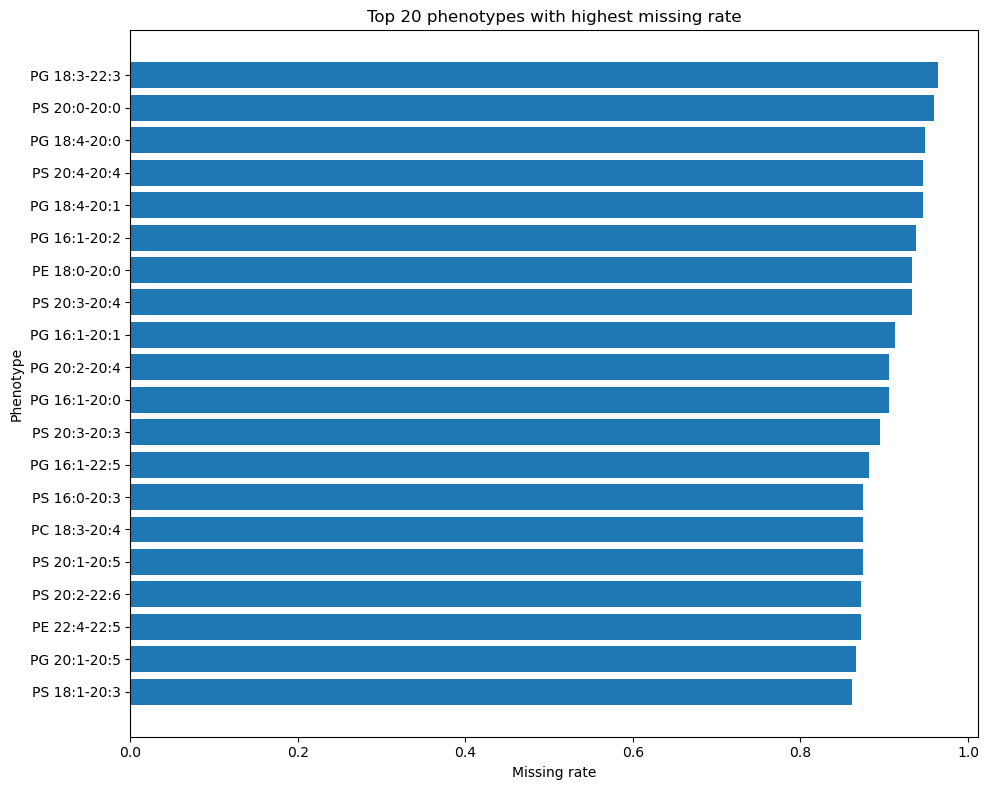

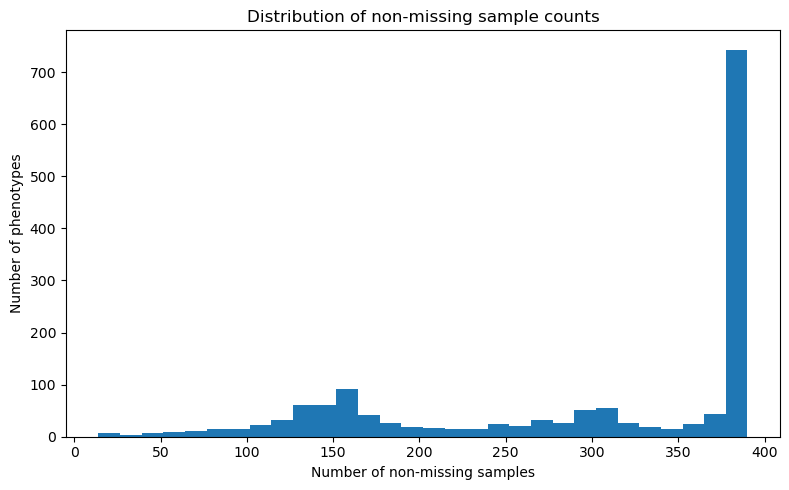

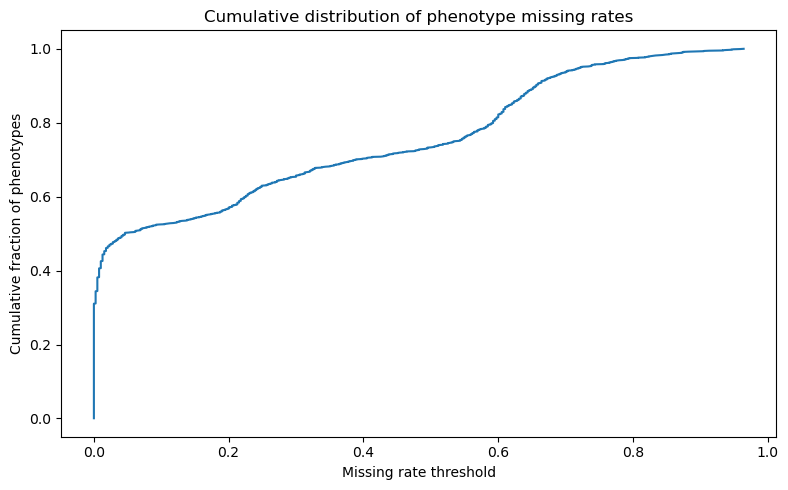


不同缺失率阈值下的表型数量：
   missing_rate_threshold  n_phenotypes_above_threshold  \
0                    0.05                           771   
1                    0.10                           736   
2                    0.20                           665   
3                    0.30                           531   
4                    0.50                           413   

   n_phenotypes_below_or_equal_threshold  
0                                    778  
1                                    813  
2                                    884  
3                                   1018  
4                                   1136  


: 

In [5]:
# ===== 可视化表型缺失情况 =====
import matplotlib.pyplot as plt

# 如果你环境里中文显示不稳定，可以先注释掉这两行
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial Unicode MS", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 再保险：确保 missing_summary 已按缺失率降序
missing_summary = missing_summary.sort_values(
    ["missing_rate", "n_missing", "phenotype"],
    ascending=[False, False, True]
).reset_index(drop=True)

# -----------------------------
# 图1：缺失率分布直方图
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(missing_summary["missing_rate"], bins=30)
plt.xlabel("Missing rate")
plt.ylabel("Number of phenotypes")
plt.title("Distribution of phenotype missing rates")
plt.tight_layout()
plt.show()

# -----------------------------
# 图2：缺失率最高的前20个表型
# -----------------------------
top_n = min(20, len(missing_summary))
top_missing = missing_summary.head(top_n).sort_values("missing_rate", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_missing["phenotype"], top_missing["missing_rate"])
plt.xlabel("Missing rate")
plt.ylabel("Phenotype")
plt.title(f"Top {top_n} phenotypes with highest missing rate")
plt.tight_layout()
plt.show()

# -----------------------------
# 图3：非缺失样本数分布
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(missing_summary["n_non_missing"], bins=30)
plt.xlabel("Number of non-missing samples")
plt.ylabel("Number of phenotypes")
plt.title("Distribution of non-missing sample counts")
plt.tight_layout()
plt.show()

# -----------------------------
# 图4：缺失率累计分布
# -----------------------------
x = sorted(missing_summary["missing_rate"].tolist())
y = [(i + 1) / len(x) for i in range(len(x))]

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel("Missing rate threshold")
plt.ylabel("Cumulative fraction of phenotypes")
plt.title("Cumulative distribution of phenotype missing rates")
plt.tight_layout()
plt.show()

# -----------------------------
# 顺手打印几个常用阈值统计
# -----------------------------
thresholds = [0.05, 0.1, 0.2, 0.3, 0.5]
threshold_summary = pd.DataFrame({
    "missing_rate_threshold": thresholds,
    "n_phenotypes_above_threshold": [
        (missing_summary["missing_rate"] > t).sum() for t in thresholds
    ],
    "n_phenotypes_below_or_equal_threshold": [
        (missing_summary["missing_rate"] <= t).sum() for t in thresholds
    ],
})

print("\n不同缺失率阈值下的表型数量：")
print(threshold_summary)